## If the figures are missing

They are tracked, so they are there. One command rebuilds all four, and no other path
writes them:

```
uv run python scripts/explainability.py
```


In [1]:
import json

import joblib

from credexp.utils import FIGURES_DIR, MODELS_DIR, PIPELINE_PATH

pipeline = joblib.load(PIPELINE_PATH)
threshold = json.loads((MODELS_DIR / "threshold.json").read_text(encoding="utf-8"))

print(f"pipeline: {' -> '.join(name for name, _ in pipeline.steps)}")
print(f"threshold: {threshold['threshold']}")
print(f"figures:  {sorted(path.name for path in FIGURES_DIR.glob('shap_*.png'))}")

pipeline: inf_to_nan -> imputer -> model
threshold: 0.49
figures:  ['shap_beeswarm.png', 'shap_waterfall_high_risk.png', 'shap_waterfall_low_risk.png']


## The model that is explained is the model that is served

`models/pipeline.joblib` is the artefact the API loads at startup, and it is what is loaded
here. The MLflow registry was the path during training; it is deliberately not in the
serving path, and its store is not in the repository, so a notebook that queried it would
only run on the machine that trained the model.


## If the figures are missing

They are tracked, so they are there. One command rebuilds all four, and no other path
writes them:

```
uv run python scripts/explainability.py
```


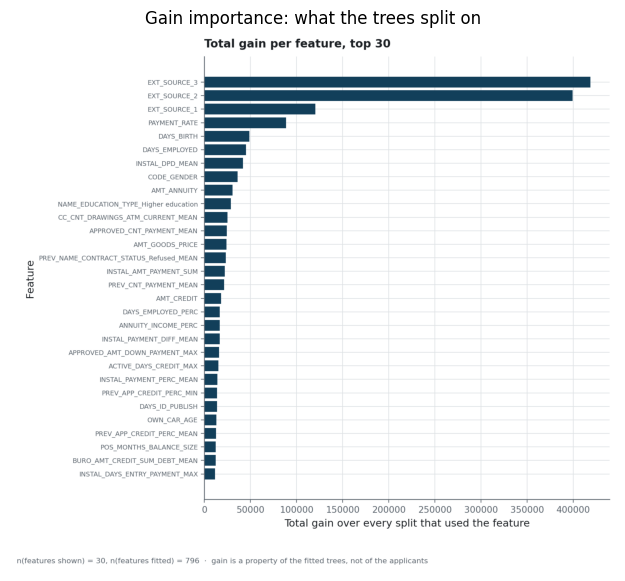

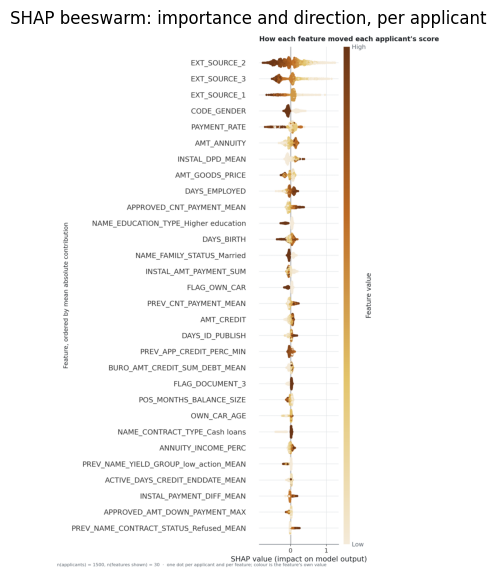

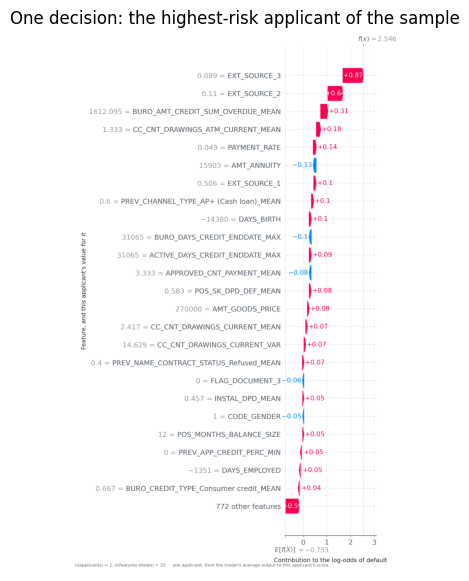

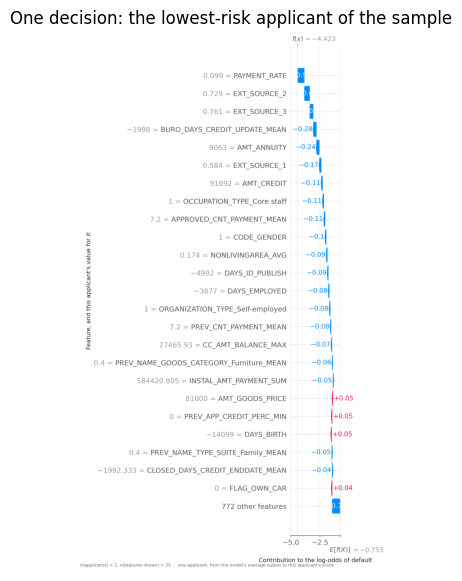

In [2]:
from PIL import Image
import matplotlib.pyplot as plt


def show(name: str, caption: str) -> None:
    """Display a published figure, at the size it was written."""
    figure = plt.figure(figsize=(11, 7))
    plt.imshow(Image.open(FIGURES_DIR / name))
    plt.axis("off")
    plt.title(caption)
    plt.show()
    plt.close(figure)


show("feature_importance_gain.png", "Gain importance: what the trees split on")
show("shap_beeswarm.png", "SHAP beeswarm: importance and direction, per applicant")
show("shap_waterfall_high_risk.png", "One decision: the highest-risk applicant of the sample")
show("shap_waterfall_low_risk.png", "One decision: the lowest-risk applicant of the sample")

## Reading the global views

### Gain importance
How much each variable reduced the loss, averaged over the trees. It is a statement about the **model's structure**, and it depends on the splits the trees happened to make: two correlated variables can share the credit arbitrarily between them.

### SHAP beeswarm
SHAP attributes each prediction additively to its features. The beeswarm shows three things at once: which features matter (vertical order), which direction they push (sign), and how much that varies across applicants (spread).

The two views usually agree on the top variables, and where they disagree it is worth looking rather than dismissing: they measure different things — one the model's internal reliance, the other the effect on the output.

## Reading a single decision

A waterfall starts at the model's average output and shows each feature pushing that particular prediction up towards risk or down away from it.

Two cases, chosen from the sample rather than picked by hand:
1. the applicant with the **highest** predicted probability
2. the applicant with the **lowest**

What this checks is not whether the model is right about them, but whether its reasons are the kind of reasons a person could be given.

## Conclusion

The final model is read through two complementary lenses: gain importance for what the trees leaned on, SHAP for how each feature moves an actual prediction.

Together they cover what a scoring model has to be able to answer — which variables dominate overall, and why *this* applicant received *this* score. Both are needed for the serving side: a score without a reason is not a decision anyone can defend.

One limit to state plainly: this explainability is built for the retained LightGBM model and its `booster_`. It is not a model-agnostic framework, and it would not transfer as-is to the other candidates.